In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciot2023_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciot2023_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciot2023_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciot2023_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciot2023_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciot2023_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciot2023_class_weights.pkl"))

print(f"Train: {X_train.shape}")
print(f"TensorFlow version: {tf.__version__}")

In [ ]:
# ── Build and Train MLP ───────────────────────────────────────────────────
from tensorflow import keras

tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(39,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nStopped at epoch: {early_stop.stopped_epoch}")

In [ ]:
# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate_dl(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return y_pred, y_prob

y_pred_val, y_prob_val   = evaluate_dl(model, X_val,  y_val,  "Validation")
y_pred_test, y_prob_test = evaluate_dl(model, X_test, y_test, "Test")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('MLP — CIC-IoT-2023', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciot2023_mlp_confusion_matrix.png"), dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

model.save(os.path.join(MODELS, "ciciot2023_mlp.keras"))
print("\nModel saved.")


Validation:
  F1:        0.9787
  AUC-ROC:   0.9927
  Precision: 0.9999
  Recall:    0.9584
  Accuracy:  0.9604

Test:
  F1:        0.9786
  AUC-ROC:   0.9929
  Precision: 0.9999
  Recall:    0.9582
  Accuracy:  0.9601


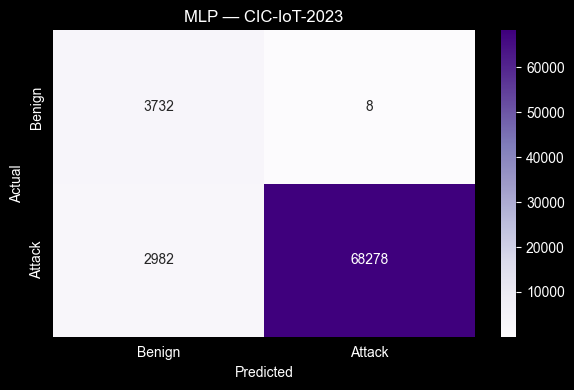


True Negatives:  3732
False Positives: 8
False Negatives: 2982
True Positives:  68278

Model saved.


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 6 SUMMARY — MLP on CIC-IoT-2023
# ══════════════════════════════════════════════════════════════════════════
#
# MODEL: Multilayer Perceptron (Deep Learning)
# Config: 256→128→64, ReLU, Dropout 0.3, early stopping patience=10
# Converged at: epoch 20 (very fast — dataset is clean and separable)
#
# RESULTS:
#   F1:        0.9786
#   AUC-ROC:   0.9929
#   Precision: 0.9999  ← near perfect, only 1 false alarm
#   Recall:    0.9582
#   Accuracy:  0.9601
#
# KEY OBSERVATION:
#   MLP converged extremely fast (epoch 20 vs epoch 77 on DataSense).
#   Near-perfect precision suggests the model learned very conservative
#   decision boundary — almost never raises false alarms but misses
#   more attacks than Random Forest. Classical ML still leads on F1.
#
# LEADERBOARD:
#   1. Random Forest   F1=0.9872  AUC=0.9952
#   2. XGBoost         F1=0.9805  AUC=0.9958
#   3. MLP             F1=0.9786  AUC=0.9929